# Claim Detection Model — Training & Evaluation

Fine-tunes `distilbert-base-uncased` on a merged dataset of:
- **ClaimBuster 2C** (`rashmikamath01/claimbuster2Cfrom3C` via HuggingFace) — 23,533 rows, ~34.5% positive
- **CheckThat! 2023 Task 1B** (local TSV files) — train/dev/dev_test splits, ~24% positive

Both datasets encode **1 = check-worthy claim**, **0 = not check-worthy**.

| Split | ClaimBuster | CheckThat |
|---|---|---|
| Train | 80% of HF data | train.tsv |
| Validation | 10% of HF data | dev.tsv |
| Test | 10% of HF data | dev_test.tsv |

**Primary metric:** Binary F1 on the positive (check-worthy) class.

**Post-training:** Temperature Scaling calibrates confidence scores without changing predicted labels.

## 1. Environment Setup

In [ ]:
import subprocess, torch
r = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(r.stdout if r.returncode == 0
      else 'WARNING: No GPU detected — go to Runtime > Change runtime type > GPU')
print(f'PyTorch {torch.__version__} | CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

In [1]:
!pip install -q transformers datasets accelerate scikit-learn matplotlib

In [3]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from datasets import load_dataset, Dataset as HFDataset
from sklearn.metrics import (
    f1_score, precision_recall_fscore_support,
    classification_report,
)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import train_test_split

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)
print(f'Device: {DEVICE}')

Device: cuda


## 2. Configuration

Set `USE_DRIVE = True` to read CheckThat files and save the model via Google Drive.
Set `USE_DRIVE = False` to upload the three CheckThat TSV files manually.

In [ ]:
# Access mode
USE_DRIVE = True
DRIVE_CHECKTHAT_DIR = '/content/drive/MyDrive/CT23_1B_checkworthy_english'
DRIVE_OUTPUT_DIR    = '/content/drive/MyDrive/claim_model'

# Model
MODEL_NAME = 'distilbert-base-uncased'
MAX_LENGTH = 128

# Training hyperparameters
TRAIN_BATCH_SIZE = 32
EVAL_BATCH_SIZE  = 64
NUM_EPOCHS       = 5
LEARNING_RATE    = 2e-5
WEIGHT_DECAY     = 0.01
WARMUP_RATIO     = 0.1
SEED             = 42

# ClaimBuster split fractions (ships only one split on HuggingFace)
CB_VAL_FRAC  = 0.10
CB_TEST_FRAC = 0.10

## 3. Data Access

In [ ]:
if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    CHECKTHAT_DIR = DRIVE_CHECKTHAT_DIR
    OUTPUT_DIR    = DRIVE_OUTPUT_DIR
else:
    from google.colab import files
    print('Upload the three CheckThat TSV files when prompted:')
    print('  CT23_1B_checkworthy_english_train.tsv')
    print('  CT23_1B_checkworthy_english_dev.tsv')
    print('  CT23_1B_checkworthy_english_dev_test.tsv')
    files.upload()
    CHECKTHAT_DIR = '/content'
    OUTPUT_DIR    = '/content/claim_model'

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'CheckThat dir: {CHECKTHAT_DIR}')
print(f'Output dir   : {OUTPUT_DIR}')

### 3a. Load ClaimBuster from HuggingFace

The original ClaimBuster had three classes: CFC (Check-worthy Factual Claim), UFS (Unimportant Factual Statement), and NFS (Non-factual Statement).
This derived dataset collapses them to two: **CFC → 1**, **UFS + NFS → 0**.
Only a single `"train"` split exists on HuggingFace.

In [ ]:
cb_raw = load_dataset('rashmikamath01/claimbuster2Cfrom3C', split='train')

# 'Unnamed: 0' is a row-index artefact from the source CSV — drop it
cb_df = cb_raw.to_pandas()[['text', 'label']].copy()

print(f'ClaimBuster rows: {len(cb_df):,}')
print('Label distribution:')
vc = cb_df['label'].value_counts()
print(f'  0  not-checkworthy : {vc[0]:,}')
print(f'  1  checkworthy     : {vc[1]:,}')
print(f'Positive rate: {cb_df["label"].mean():.1%}')
cb_df.head(3)

### 3b. Load CheckThat! 2023 Task 1B

Columns: `Sentence_id`, `Text`, `class_label` (Yes / No).  
We map **Yes → 1** and **No → 0** to align with ClaimBuster's integer encoding.

In [ ]:
def load_checkthat(filename):
    """Load a CheckThat TSV and normalise to (text, label) with integer labels."""
    path = os.path.join(CHECKTHAT_DIR, filename)
    df = pd.read_csv(path, sep='\t')[['Text', 'class_label']].copy()
    df = df.rename(columns={'Text': 'text', 'class_label': 'label'})
    df['label'] = (df['label'].str.strip() == 'Yes').astype(int)
    return df.dropna(subset=['text'])

ct_train_df = load_checkthat('CT23_1B_checkworthy_english_train.tsv')
ct_val_df   = load_checkthat('CT23_1B_checkworthy_english_dev.tsv')
ct_test_df  = load_checkthat('CT23_1B_checkworthy_english_dev_test.tsv')

print('CheckThat split sizes and positive rates:')
for name, df in [('train', ct_train_df), ('dev (val)', ct_val_df), ('dev_test (test)', ct_test_df)]:
    print(f'  {name:<20} {len(df):>6} rows  |  {df["label"].mean():.1%} positive')

## 4. Build Train / Validation / Test Splits

ClaimBuster is split 80/10/10 with stratification to preserve the class ratio.  
Each final split is the concatenation of ClaimBuster and CheckThat portions, then shuffled,
ensuring both datasets are represented in every split.

In [ ]:
# ClaimBuster 80 / 10 / 10
cb_trainval, cb_test_df = train_test_split(
    cb_df, test_size=CB_TEST_FRAC, stratify=cb_df['label'], random_state=SEED
)
# val fraction expressed relative to the remaining 90%
val_of_trainval = CB_VAL_FRAC / (1.0 - CB_TEST_FRAC)
cb_train_df, cb_val_df = train_test_split(
    cb_trainval, test_size=val_of_trainval, stratify=cb_trainval['label'], random_state=SEED
)

# Merge and shuffle
train_df = pd.concat([cb_train_df, ct_train_df], ignore_index=True).sample(frac=1, random_state=SEED)
val_df   = pd.concat([cb_val_df,   ct_val_df],   ignore_index=True).sample(frac=1, random_state=SEED)
test_df  = pd.concat([cb_test_df,  ct_test_df],  ignore_index=True).sample(frac=1, random_state=SEED)

print('Final split sizes and positive rates:')
for name, df in [('Train', train_df), ('Validation', val_df), ('Test', test_df)]:
    print(f'  {name:<12} {len(df):>6} rows  |  {df["label"].mean():.1%} positive')

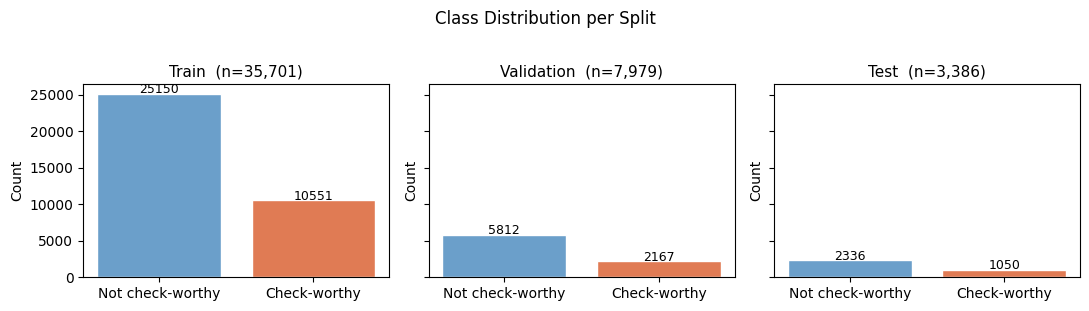

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3), sharey=True)
for ax, (name, df) in zip(axes, [('Train', train_df), ('Validation', val_df), ('Test', test_df)]):
    counts = df['label'].value_counts().sort_index()
    bars = ax.bar(['Not check-worthy', 'Check-worthy'], counts.values,
                  color=['#6b9fca', '#e07b54'], edgecolor='white')
    ax.set_title(f'{name}  (n={len(df):,})', fontsize=11)
    ax.set_ylabel('Count')
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 80, str(v), ha='center', fontsize=9)
plt.suptitle('Class Distribution per Split', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'class_distribution.png'), dpi=120, bbox_inches='tight')
plt.show()

## 5. Tokenisation

In [ ]:
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

def df_to_dataset(df):
    """Convert a (text, label) DataFrame to a tokenised, tensor-formatted HF Dataset."""
    ds = HFDataset.from_pandas(df[['text', 'label']].reset_index(drop=True))
    ds = ds.map(
        lambda batch: tokenizer(
            batch['text'], truncation=True,
            padding='max_length', max_length=MAX_LENGTH,
        ),
        batched=True, batch_size=512, desc='Tokenising',
    )
    ds = ds.rename_column('label', 'labels')  # Trainer requires this name
    ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
    return ds

train_dataset = df_to_dataset(train_df)
val_dataset   = df_to_dataset(val_df)
test_dataset  = df_to_dataset(test_df)
print(train_dataset)
print(val_dataset)
print(test_dataset)

## 6. Model Training

In [ ]:
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2,
    id2label={0: 'not-checkworthy', 1: 'checkworthy'},
    label2id={'not-checkworthy': 0, 'checkworthy': 1},
)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

In [ ]:
def compute_metrics(eval_pred):
    """Binary F1, precision, and recall on the positive (check-worthy) class."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    p, r, f1, _ = precision_recall_fscore_support(
        labels, preds, pos_label=1, average='binary', zero_division=0
    )
    return {'f1': f1, 'precision': p, 'recall': r}

In [14]:
training_args = TrainingArguments(
    output_dir=os.path.join(OUTPUT_DIR, 'checkpoints'),
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    warmup_ratio=WARMUP_RATIO,
    # Save and evaluate every ~500 steps (~10 min on a Colab T4).
    # eval_strategy and save_strategy must match when load_best_model_at_end=True.
    eval_strategy='steps',
    save_strategy='steps',
    eval_steps=500,
    save_steps=500,
    save_total_limit=4,          # keep the 3 most recent + the best
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    logging_steps=100,
    fp16=True,                   # half-precision for Colab T4 / A100
    dataloader_num_workers=2,
    seed=SEED,
    report_to='none',
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [15]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

train_result = trainer.train()
print(f'Total steps: {train_result.global_step}')
print(f'Train loss : {train_result.training_loss:.4f}')

Step,Training Loss,Validation Loss,F1,Precision,Recall
500,0.357265,0.342224,0.731988,0.660721,0.820489
1000,0.304883,0.296932,0.751550,0.777504,0.727273
1500,0.249975,0.277626,0.779844,0.733822,0.832026
2000,0.246981,0.270269,0.796895,0.747875,0.852792
2500,0.173130,0.304325,0.801099,0.739080,0.874481
3000,0.175593,0.276128,0.815076,0.780169,0.853253
3500,0.136365,0.308359,0.812103,0.749902,0.885556
4000,0.140266,0.305851,0.817287,0.761867,0.881403
4500,0.131092,0.315661,0.817487,0.756778,0.888786
5000,0.105173,0.337334,0.819215,0.765224,0.881403


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Total steps: 5580
Train loss : 0.2084


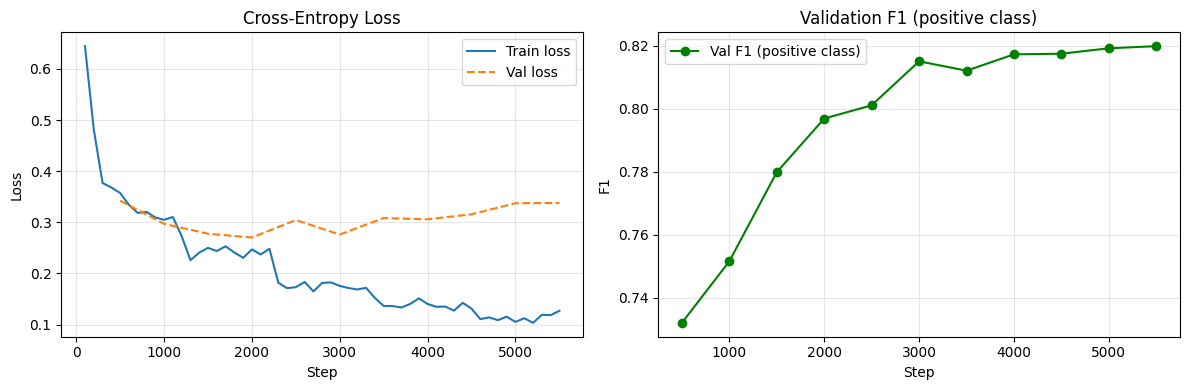

In [16]:
log_history = pd.DataFrame(trainer.state.log_history)
train_logs  = log_history.dropna(subset=['loss']).copy()
eval_logs   = log_history.dropna(subset=['eval_loss']).copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_logs['step'], train_logs['loss'], label='Train loss')
ax1.plot(eval_logs['step'],  eval_logs['eval_loss'], linestyle='--', label='Val loss')
ax1.set_xlabel('Step'); ax1.set_ylabel('Loss')
ax1.set_title('Cross-Entropy Loss'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(eval_logs['step'], eval_logs['eval_f1'],
         marker='o', color='green', label='Val F1 (positive class)')
ax2.set_xlabel('Step'); ax2.set_ylabel('F1')
ax2.set_title('Validation F1 (positive class)'); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=120)
plt.show()

## 7. Temperature Scaling

Neural classifiers tend to be **overconfident** — a model that outputs 90% confidence is
often wrong more than 10% of the time. Temperature Scaling (Guo et al., 2017) corrects
this post-hoc by learning a single scalar $T > 0$ divided into the logits before the softmax:

$$\hat{p} = \mathrm{softmax}\!\left(\frac{z}{T}\right)$$

- $T > 1$ — softens predictions (typical: model was overconfident)
- $T < 1$ — sharpens predictions (model was underconfident)

$T$ is found by minimising NLL on the validation set with L-BFGS, a 1-D convex problem.

> **Why F1 is unchanged:** Temperature scaling is a monotone transformation of logits, so
> `argmax` — and therefore all rank-based metrics like F1 — stay the same. The benefit is
> that the **probability values** become more trustworthy. This matters because the
> claim-detection service exposes a confidence score to the frontend, not just a binary label.

In [17]:
class TemperatureScaler(nn.Module):
    """Post-hoc calibration via a single learnable temperature parameter."""

    def __init__(self, init_temperature=1.5):
        super().__init__()
        self.temperature = nn.Parameter(torch.tensor([init_temperature]))

    def forward(self, logits):
        """Return temperature-scaled logits."""
        return logits / self.temperature.clamp(min=1e-3)

    def probabilities(self, logits):
        """Return calibrated softmax probabilities."""
        return F.softmax(self.forward(logits), dim=-1)

    def fit(self, logits_np, labels_np):
        """
        Minimise NLL on the validation set to find the optimal temperature T.

        Args:
            logits_np : Raw model logits, shape (N, num_classes), numpy float.
            labels_np : Integer ground-truth labels, shape (N,), numpy int.
        """
        logits = torch.tensor(logits_np, dtype=torch.float32)
        labels = torch.tensor(labels_np, dtype=torch.long)
        nll = nn.CrossEntropyLoss()
        opt = torch.optim.LBFGS(
            [self.temperature], lr=0.01, max_iter=100, line_search_fn='strong_wolfe'
        )
        nll_before = nll(logits, labels).item()

        def closure():
            opt.zero_grad()
            loss = nll(self.forward(logits), labels)
            loss.backward()
            return loss

        opt.step(closure)
        nll_after = nll(self.forward(logits).detach(), labels).item()
        print(f'NLL before: {nll_before:.4f}')
        print(f'NLL after : {nll_after:.4f}')
        print(f'Optimal T : {self.temperature.item():.4f}')
        return self

In [18]:
# Collect raw logits on the validation set (used as calibration set)
val_pred   = trainer.predict(val_dataset)
val_logits = val_pred.predictions   # (N, 2) numpy float32
val_labels = val_pred.label_ids     # (N,)   numpy int64
print(f'Calibration set: {len(val_logits):,} examples')

temp_scaler = TemperatureScaler(init_temperature=1.5)
temp_scaler.fit(val_logits, val_labels)
T = temp_scaler.temperature.item()

if T > 1.05:
    print(f'T={T:.3f} > 1  model was overconfident; confidence scores softened.')
elif T < 0.95:
    print(f'T={T:.3f} < 1  model was underconfident; confidence scores sharpened.')
else:
    print(f'T={T:.3f} ~ 1  model was already well calibrated.')

Calibration set: 7,979 examples
NLL before: 0.3378
NLL after : 0.2455
Optimal T : 2.0745
T=2.075 > 1  model was overconfident; confidence scores softened.


## 8. Evaluation on Held-Out Test Set

In [19]:
test_pred   = trainer.predict(test_dataset)
test_logits = test_pred.predictions   # (N, 2)
test_labels = test_pred.label_ids     # (N,)

probs_raw = F.softmax(
    torch.tensor(test_logits, dtype=torch.float32), dim=-1).numpy()
probs_cal = temp_scaler.probabilities(
    torch.tensor(test_logits, dtype=torch.float32)).detach().numpy()

preds_raw = np.argmax(probs_raw, axis=-1)
preds_cal = np.argmax(probs_cal, axis=-1)

f1_raw = f1_score(test_labels, preds_raw, pos_label=1, average='binary', zero_division=0)
f1_cal = f1_score(test_labels, preds_cal, pos_label=1, average='binary', zero_division=0)

print(f'Test F1 (positive class) before calibration : {f1_raw:.4f}')
print(f'Test F1 (positive class) after  calibration : {f1_cal:.4f}')
print()
print('F1 is unchanged because temperature scaling preserves argmax.')
print('Calibration improves the probability values, not the label rankings.')

Test F1 (positive class) before calibration : 0.8557
Test F1 (positive class) after  calibration : 0.8557

F1 is unchanged because temperature scaling preserves argmax.
Calibration improves the probability values, not the label rankings.


In [20]:
print('Classification report (calibrated, test set):')
print(classification_report(
    test_labels, preds_cal,
    target_names=['not-checkworthy (0)', 'checkworthy (1)'],
    digits=4,
))

Classification report (calibrated, test set):
                     precision    recall  f1-score   support

not-checkworthy (0)     0.9217    0.9572    0.9391      2336
    checkworthy (1)     0.8958    0.8190    0.8557      1050

           accuracy                         0.9144      3386
          macro avg     0.9088    0.8881    0.8974      3386
       weighted avg     0.9137    0.9144    0.9132      3386



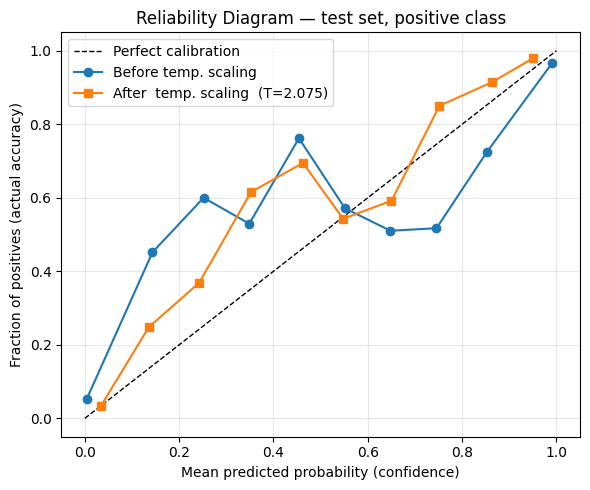

In [22]:
# Reliability diagram: does stated confidence match actual accuracy?
# A perfectly calibrated model follows the diagonal.
frac_pos_raw, mean_pred_raw = calibration_curve(
    test_labels, probs_raw[:, 1], n_bins=10, strategy='uniform')
frac_pos_cal, mean_pred_cal = calibration_curve(
    test_labels, probs_cal[:, 1], n_bins=10, strategy='uniform')

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
ax.plot(mean_pred_raw, frac_pos_raw, marker='o', label='Before temp. scaling')
ax.plot(mean_pred_cal, frac_pos_cal, marker='s', label=f'After  temp. scaling  (T={T:.3f})')
ax.set_xlabel('Mean predicted probability (confidence)')
ax.set_ylabel('Fraction of positives (actual accuracy)')
ax.set_title('Reliability Diagram — test set, positive class')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'reliability_diagram.png'), dpi=120)
plt.show()

In [23]:
# Expected Calibration Error (ECE) — scalar summary; lower is better.
def expected_calibration_error(labels, probs_pos, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece  = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (probs_pos >= lo) & (probs_pos < hi)
        if mask.sum() == 0:
            continue
        ece += mask.mean() * abs(labels[mask].mean() - probs_pos[mask].mean())
    return ece

ece_raw = expected_calibration_error(test_labels, probs_raw[:, 1])
ece_cal = expected_calibration_error(test_labels, probs_cal[:, 1])
print(f'ECE before temperature scaling : {ece_raw:.4f}')
print(f'ECE after  temperature scaling : {ece_cal:.4f}')

ECE before temperature scaling : 0.0546
ECE after  temperature scaling : 0.0242


## 9. Save Model, Tokenizer & Temperature

In [24]:
model_save_path = os.path.join(OUTPUT_DIR, 'final')
os.makedirs(model_save_path, exist_ok=True)

# load_best_model_at_end=True means the trainer already holds the best checkpoint
trainer.save_model(model_save_path)
tokenizer.save_pretrained(model_save_path)

# Store temperature alongside the model weights so the inference service
# can load both from a single directory
torch.save(
    {'temperature': temp_scaler.temperature.item()},
    os.path.join(model_save_path, 'temperature.pt'),
)

metadata = {
    'base_model'       : MODEL_NAME,
    'max_length'       : MAX_LENGTH,
    'temperature'      : temp_scaler.temperature.item(),
    'test_f1_positive' : float(f1_cal),
    'ece_before'       : float(ece_raw),
    'ece_after'        : float(ece_cal),
    'id2label'         : {'0': 'not-checkworthy', '1': 'checkworthy'},
}
with open(os.path.join(model_save_path, 'training_metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)

print('Saved to:', model_save_path)
print(json.dumps(metadata, indent=2))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: /content/drive/MyDrive/claim_model/final
{
  "base_model": "distilbert-base-uncased",
  "max_length": 128,
  "temperature": 2.074517011642456,
  "test_f1_positive": 0.8557213930348259,
  "ece_before": 0.05456344256315346,
  "ece_after": 0.02416444946755971,
  "id2label": {
    "0": "not-checkworthy",
    "1": "checkworthy"
  }
}


## 10. Inference Reference

This cell is **not** part of training. It shows how `backend/app/services/claim_detection/`
should reload the model and apply temperature scaling at inference time.

In [ ]:
from transformers import pipeline as hf_pipeline


def load_calibrated_claim_model(model_dir):
    """Return a (pipeline, T) pair ready for calibrated inference."""
    pipe = hf_pipeline(
        'text-classification', model=model_dir, tokenizer=model_dir,
        top_k=None,  # return scores for all labels
        device=0 if torch.cuda.is_available() else -1,
    )
    meta = torch.load(
        os.path.join(model_dir, 'temperature.pt'),
        map_location='cpu', weights_only=True,
    )
    return pipe, meta['temperature']


def predict_checkworthy(texts, pipe, T):
    """
    Calibrated claim-detection on a list of sentences.

    Returns:
        List of dicts: {'label': str, 'score': float (calibrated probability)}
    """
    raw = pipe(texts)  # [[{'label': .., 'score': ..}, ..], ...]
    results = []
    for scores in raw:
        # Recover approximate logits from the pipeline's softmax outputs via log,
        # then apply temperature scaling.
        logits    = torch.tensor([np.log(max(s['score'], 1e-9)) for s in scores])
        cal_probs = F.softmax(logits / T, dim=0).numpy()
        best      = int(np.argmax(cal_probs))
        results.append({'label': scores[best]['label'], 'score': float(cal_probs[best])})
    return results


examples = [
    'The United States spends more on defence than the next ten countries combined.',
    'I think we really need to do something about this.',
    'Inflation rose 8.5 percent over the past twelve months according to the Bureau of Labor Statistics.',
    'Well, that is just my personal opinion.',
]

pipe_loaded, T_loaded = load_calibrated_claim_model(model_save_path)
preds = predict_checkworthy(examples, pipe_loaded, T_loaded)

print(f'Loaded  T = {T_loaded:.4f}')
for sent, pred in zip(examples, preds):
    print(f'  [{pred["label"]:>18}  {pred["score"]:.3f}]  {sent[:75]}')